In [1]:
# Import dependencies
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.interpolate import interp1d
import random
from shapely.geometry import Point
import pickle
import xarray as xr
import geopandas as gpd
from shapely.geometry import Point, Polygon

pd.set_option('display.max_columns', None)

from utils.cf_helper import *
from utils.config import *
from utils.functions import *

In [2]:
## Change working directory
os.chdir('../')

# Prepare site polygons for import to Web Soil Service

The SSURGO web download service only allows 100 polygons per AOI. I limit the download size by including only the LaTour plots that we use in the tree growth analysis.

In [3]:
# Read plot data with polygons
plot_poly = gpd.read_file('Input_data/Site/all_unit_polygons.shp')

# Consistent lat/lon for all units
plot_poly['Latitude'] = plot_poly.centroid.y
plot_poly['Longitude'] = plot_poly.centroid.x

plot_poly

/var/folders/10/59zmyyyn291b5qydrr69_j6h0000gn/T/ipykernel_94011/2728651419.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  plot_poly['Latitude'] = plot_poly.centroid.y
/var/folders/10/59zmyyyn291b5qydrr69_j6h0000gn/T/ipykernel_94011/2728651419.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  plot_poly['Longitude'] = plot_poly.centroid.x


,PlotID,Latitude,Longitude,Site,UnitID,UniqueID,geometry
0,FFS7CONTROL,36.581771,-118.762344,Sequoia_FFS,FFS7CONTROL,Sequoia_FFS_FFS7CONTROL,"POLYGON ((-118.76289 36.58132, -118.76291 36.5..."
1,FFS5BURN,36.585279,-118.754700,Sequoia_FFS,FFS5BURN,Sequoia_FFS_FFS5BURN,"POLYGON ((-118.75524 36.58482, -118.75526 36.5..."
2,FFS6BURN,36.585635,-118.759024,Sequoia_FFS,FFS6BURN,Sequoia_FFS_FFS6BURN,"POLYGON ((-118.75955 36.58519, -118.75957 36.5..."
3,FFS2BURN,36.595484,-118.746431,Sequoia_FFS,FFS2BURN,Sequoia_FFS_FFS2BURN,"POLYGON ((-118.74697 36.59503, -118.74699 36.5..."
4,LOTHAR,36.562389,-118.741997,Sequoia_Tharp,LOTHAR,Sequoia_Tharp_LOTHAR,"POLYGON ((-118.74257 36.56191, -118.74259 36.5..."
...,...,...,...,...,...,...,...
286,217,40.629233,-121.668217,LaTour,217,LaTour_217,"POLYGON ((-121.66808 40.62923, -121.66808 40.6..."
287,218,40.625433,-121.668600,LaTour,218,LaTour_218,"POLYGON ((-121.66847 40.62543, -121.66847 40.6..."
288,219,40.621633,-121.668300,LaTour,219,LaTour_219,"POLYGON ((-121.66817 40.62163, -121.66817 40.6..."
289,220,40.618417,-121.668467,LaTour,220,LaTour_220,"POLYGON ((-121.66833 40.61842, -121.66833 40.6..."


In [4]:
## Determine subset of LaTour plots that are used in analysis
lt_exp_plots = pd.read_csv('Outputs/Processed_data_for_statespace/LaTour/pft_df.csv')
lt_exp_plots['UnitID'].unique()

array([ 10,  22,  23,  47,  64,  66,  87,  88,  99, 101, 102, 119, 120,
       122, 123, 124, 125, 126, 130, 150, 156, 159, 181, 190])

In [5]:
## Reduce plot poly by removing extra LaTour plots
to_rm = plot_poly.loc[(plot_poly['Site']=='LaTour') & (plot_poly['UnitID'].isin([str(i) for i in lt_exp_plots['UnitID'].unique()])==False)]
plot_poly.drop(to_rm.index, inplace=True)
plot_poly

,PlotID,Latitude,Longitude,Site,UnitID,UniqueID,geometry
0,FFS7CONTROL,36.581771,-118.762344,Sequoia_FFS,FFS7CONTROL,Sequoia_FFS_FFS7CONTROL,"POLYGON ((-118.76289 36.58132, -118.76291 36.5..."
1,FFS5BURN,36.585279,-118.754700,Sequoia_FFS,FFS5BURN,Sequoia_FFS_FFS5BURN,"POLYGON ((-118.75524 36.58482, -118.75526 36.5..."
2,FFS6BURN,36.585635,-118.759024,Sequoia_FFS,FFS6BURN,Sequoia_FFS_FFS6BURN,"POLYGON ((-118.75955 36.58519, -118.75957 36.5..."
3,FFS2BURN,36.595484,-118.746431,Sequoia_FFS,FFS2BURN,Sequoia_FFS_FFS2BURN,"POLYGON ((-118.74697 36.59503, -118.74699 36.5..."
4,LOTHAR,36.562389,-118.741997,Sequoia_Tharp,LOTHAR,Sequoia_Tharp_LOTHAR,"POLYGON ((-118.74257 36.56191, -118.74259 36.5..."
...,...,...,...,...,...,...,...
220,150,40.618500,-121.695600,LaTour,150,LaTour_150,"POLYGON ((-121.69547 40.6185, -121.69547 40.61..."
226,156,40.622550,-121.690850,LaTour,156,LaTour_156,"POLYGON ((-121.69072 40.62255, -121.69072 40.6..."
229,159,40.632817,-121.691100,LaTour,159,LaTour_159,"POLYGON ((-121.69097 40.63282, -121.69097 40.6..."
250,181,40.625750,-121.686433,LaTour,181,LaTour_181,"POLYGON ((-121.6863 40.62575, -121.6863 40.625..."


In [6]:
# Export to upload to SSURGO WSS
plot_poly.to_file('Outputs/Shapefiles_for_WSS/unit_polygons_for_WSS.shp')

# Download data from Web Soil Service

The next step is to upload these polygons to the SSURGO web soil survey (https://websoilsurvey.nrcs.usda.gov/app/) as the AOI. Then download the soils data as a zipfile. This step happens outside of this Jupyter notebook.

# Process SSURGO data

In [7]:
def extract_ssurgo_shp(folder, soil_dir = 'Input_data/Soil', spatial_dir = 'spatial/'):
  '''Loads shapefiles from a downloaded SSURGO AOI query'''
  flpth = Path(soil_dir, folder, spatial_dir)
  aoi = gpd.read_file(Path(flpth, 'aoi_a_aoi.shp'))
  soilmu_a = gpd.read_file(Path(flpth, 'soilmu_a_aoi.shp'))
  soilmu_l = gpd.read_file(Path(flpth, 'soilmu_l_aoi.shp'))
  soilmu_p = gpd.read_file(Path(flpth, 'soilmu_p_aoi.shp'))
  soilsf_l = gpd.read_file(Path(flpth, 'soilsf_l_aoi.shp'))
  soilsf_p = gpd.read_file(Path(flpth, 'soilsf_p_aoi.shp'))
  for d, n in zip([aoi, soilmu_a, soilmu_l, soilmu_p, soilsf_l, soilsf_p],
                  ['aoi', 'soilmu_a', 'soilmu_l', 'soilmu_p', 'soilsf_l', 'soilsf_p']):
    if len(d) == 0:
      print("No entries in {}".format(n))
  return aoi, soilmu_a, soilmu_l, soilmu_p, soilsf_l, soilsf_p

In [8]:
## Extract soils data from SSURGO download
aoi, soilmu, _, _, _, _ = extract_ssurgo_shp(folder = 'wss_aoi_2025-03-11_18-03-43')

No entries in soilmu_l
No entries in soilmu_p
No entries in soilsf_l
No entries in soilsf_p


In [9]:
## Check that area symbols include 'CA724', 'CA792', 'CA607', 'CA750', 'CA731', 'CA693'
soilmu['AREASYMBOL'].unique()

array(['CA693', 'CA724', 'CA607', 'CA731', 'CA750', 'CA792'], dtype=object)

In [10]:
## Associate each polygon in soilmu with a plot from plot_poly
## Logic: a soil polygon is associated with a plot if its centroid falls within the plot polygon

## Add new columns to soil dataframe
soil_df = soilmu.copy()
soil_df['Site'] = np.nan
soil_df['UnitID'] = np.nan
soil_df['unique_nm'] = np.nan

for i in soilmu.index:
  plot = plot_poly.loc[plot_poly.contains(soilmu.loc[i,'geometry'].centroid)]
  # Check that each soil polygon is associated with only one plot
  if len(plot)!=1:
    print(i)
  # soil_df.loc[i,'PlotID'] = plot.iloc[0]['PlotID']
  soil_df.loc[i,'Site'] = plot.iloc[0]['Site']
  soil_df.loc[i, 'UnitID'] = plot.iloc[0]['UnitID']
  soil_df.loc[i, 'unique_nm'] = plot.iloc[0]['UniqueID']

soil_df

127
128


/var/folders/10/59zmyyyn291b5qydrr69_j6h0000gn/T/ipykernel_94011/4037908583.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'UPFUb' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  soil_df.loc[i,'Site'] = plot.iloc[0]['Site']
/var/folders/10/59zmyyyn291b5qydrr69_j6h0000gn/T/ipykernel_94011/4037908583.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'MCK 13-3 C' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  soil_df.loc[i, 'UnitID'] = plot.iloc[0]['UnitID']
/var/folders/10/59zmyyyn291b5qydrr69_j6h0000gn/T/ipykernel_94011/4037908583.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'UPFUb_MCK 13-3 C' has dtype incompatible with float64, please explic

,AREASYMBOL,SPATIALVER,MUSYM,MUKEY,geometry,Site,UnitID,unique_nm
0,CA693,3,7523,1652151,"POLYGON ((-120.16199 39.06691, -120.16201 39.0...",UPFUb,MCK 13-3 C,UPFUb_MCK 13-3 C
1,CA693,3,7232,1652213,"POLYGON ((-120.17553 39.11341, -120.17589 39.1...",UPFU,BLK 1-4 T,UPFU_BLK 1-4 T
2,CA693,3,7231,1652212,"POLYGON ((-120.17576 39.11247, -120.1761 39.11...",UPFU,BLK 1-4 T,UPFU_BLK 1-4 T
3,CA693,3,7042,1652070,"POLYGON ((-120.18784 39.14804, -120.18783 39.1...",UPFUb,WRD 20-9 C,UPFUb_WRD 20-9 C
4,CA693,3,7522,1652150,"POLYGON ((-120.14152 39.05313, -120.14152 39.0...",UPFU,MCK 13-1 T,UPFU_MCK 13-1 T
...,...,...,...,...,...,...,...,...
135,CA792,4,4148,2924647,"POLYGON ((-118.74257 36.56191, -118.74259 36.5...",Sequoia_Tharp,LOTHAR,Sequoia_Tharp_LOTHAR
136,CA792,4,4148,2924647,"POLYGON ((-118.73359 36.55944, -118.73361 36.5...",Sequoia_Tharp,UPLOG,Sequoia_Tharp_UPLOG
137,CA792,4,4148,2924647,"POLYGON ((-118.73705 36.55854, -118.73707 36.5...",Sequoia_Tharp,LOLOG,Sequoia_Tharp_LOLOG
138,CA792,4,3141,2766861,"POLYGON ((-118.74697 36.59503, -118.74698 36.5...",Sequoia_FFS,FFS2BURN,Sequoia_FFS_FFS2BURN


In [11]:
## A few checks

## Check the soil survey(s) associated with each site
for s in soil_df['Site'].unique():
  print(s)
  print(soil_df.loc[soil_df['Site']==s, 'AREASYMBOL'].unique())

## Check that we don't have any null sites (i.e., orphaned soil polygons)
assert len(soil_df.loc[soil_df['unique_nm'].isnull()])==0

## Check that we didn't drop any plots
print(len(soil_df['unique_nm'].unique()), len(plot_poly['UniqueID'].unique()))

## ... if we did drop plots, which ones??
[i for i in plot_poly['UniqueID'].unique() if i not in soil_df['unique_nm'].unique()]

UPFUb
['CA693']
UPFU
['CA693']
Blodgett_FFS
['CA724']
LaTour
['CA607']
STEF-VDT
['CA731']
Teakettle
['CA750']
Sequoia_FFS
['CA792']
Sequoia_Tharp
['CA792']
95 96


['Teakettle_BS1']

In [12]:
## All the data are here, but the plots are imperfectly matched. Need to do this step to match
soil_df = plot_poly.overlay(soil_df, how='intersection')

In [13]:
## Revise column names
soil_df.drop(columns=['Site_2', 'UnitID_2'], inplace=True)
soil_df.rename(columns={'Site_1':'Site', 'UnitID_1':'UnitID'}, inplace=True)

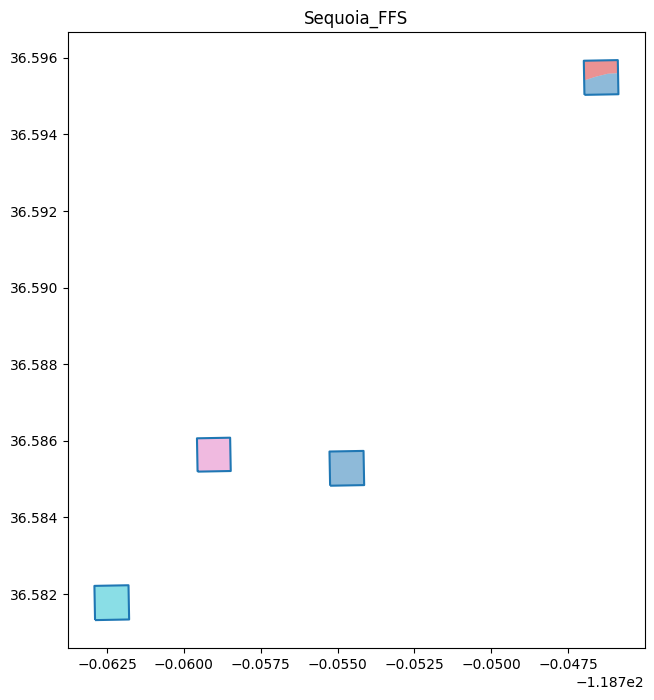

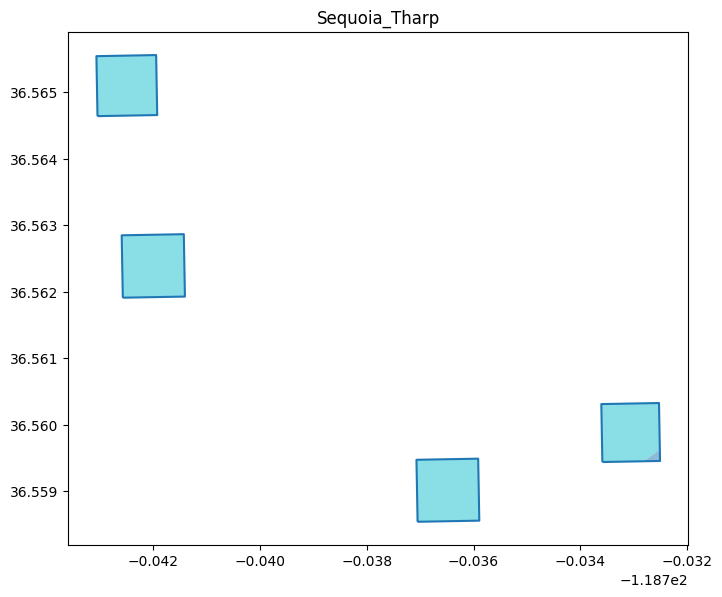

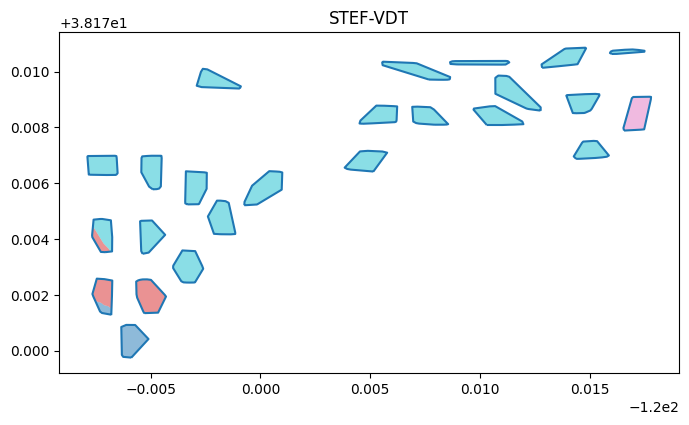

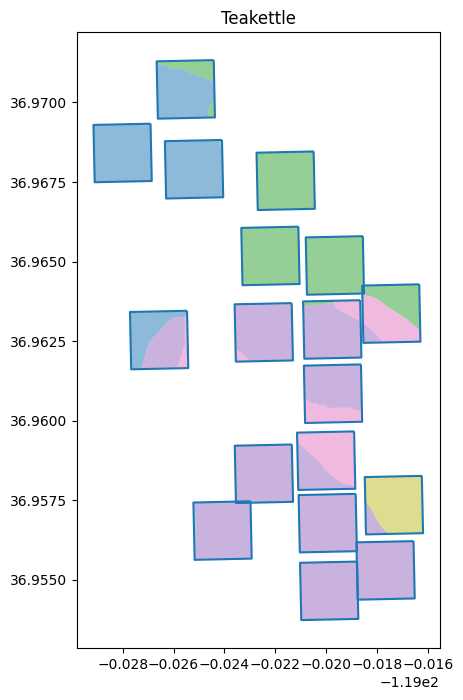

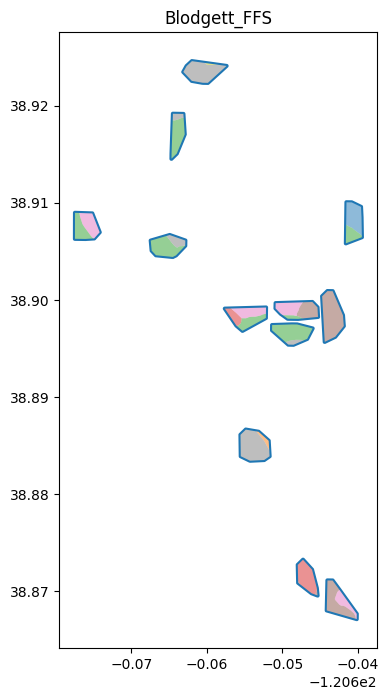

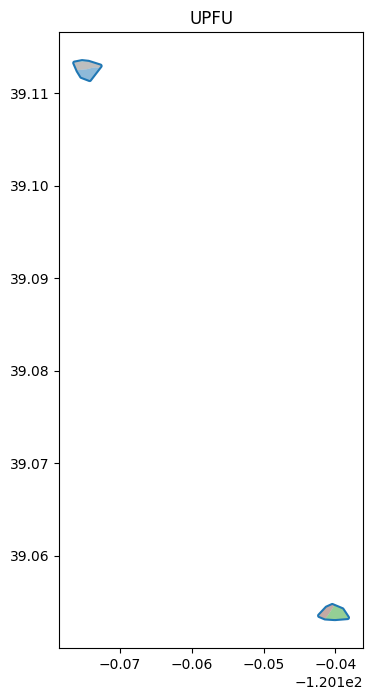

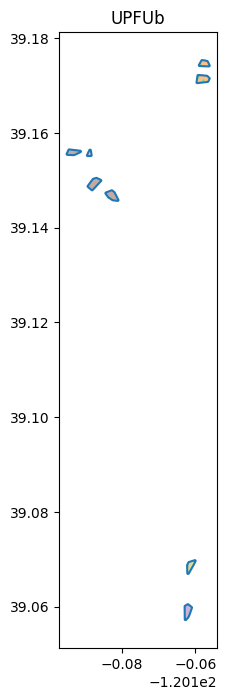

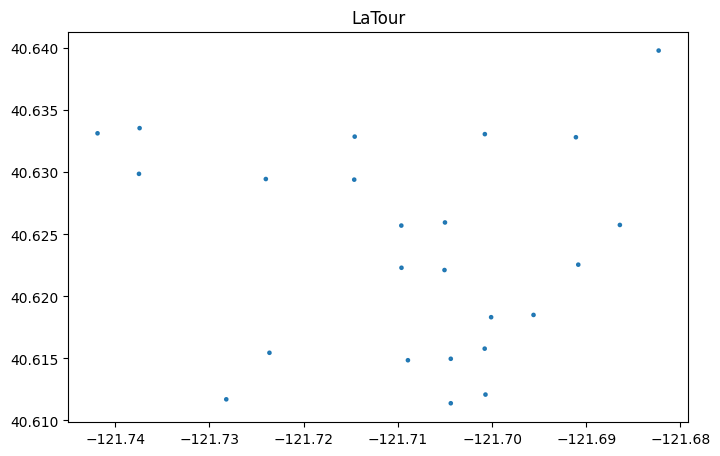

In [14]:
# Visually verify complete soil data for each site (no missing polygons)
for site in plot_poly['Site'].unique():
  fig, ax = plt.subplots(figsize = (8,8))
  plot_poly.loc[plot_poly['Site']==site].exterior.plot(ax=ax)
  soil_df.loc[soil_df['Site']==site].plot('MUKEY', ax = ax, alpha = 0.5)
  ax.set_title(site)

In [15]:
### Load SSURGO variables processed via `process_ssurgo_variables.R`

all_soils = pd.read_csv('Outputs/all_unit_soils.csv')
all_soils

,comppct.r,compname,majcompflag,mukey,cokey,ksat,cec,awc,total_depth,musym,muname,muacres
0,4,McCarthy,No,459921,25406102,NaN,NaN,NaN,NaN,AaB,Aiken loam_2 to 9 percent slopes_low ffd,8954
1,85,Aiken,Yes,459921,25406103,10.66,11.49,0.17,230.0,AaB,Aiken loam_2 to 9 percent slopes_low ffd,8954
2,8,Cohasset,No,459921,25406104,NaN,NaN,NaN,NaN,AaB,Aiken loam_2 to 9 percent slopes_low ffd,8954
3,3,Guenoc,No,459921,25406105,NaN,NaN,NaN,NaN,AaB,Aiken loam_2 to 9 percent slopes_low ffd,8954
4,8,Cohasset,No,459922,25406106,NaN,NaN,NaN,NaN,AaC,Aiken loam_8 to 15 percent slopes,6321
...,...,...,...,...,...,...,...,...,...,...,...,...
4541,23,Rock outcrop,Yes,3233140,25899206,NaN,NaN,NaN,NaN,5134,Littlebaugh_warm-Rock outcrop_granitic-Mororoc...,2593
4542,12,Canyonview,No,3233140,25899207,81.76,11.15,0.09,155.0,5134,Littlebaugh_warm-Rock outcrop_granitic-Mororoc...,2593
4543,45,Littlebaugh,Yes,3233140,25899208,66.40,8.39,0.07,200.0,5134,Littlebaugh_warm-Rock outcrop_granitic-Mororoc...,2593
4544,15,Mororock,Yes,3233140,25899209,9.84,20.33,0.16,153.0,5134,Littlebaugh_warm-Rock outcrop_granitic-Mororoc...,2593


In [16]:
def weight_soil_var(df, mu, var):
  '''Finds the weighted average of a soil variable (var) within a mapunit (mu) based on the percent of mapunit associated with a component.'''
  '''Make sure to use mukey and not musym'''
  mu_df = df.loc[df['mukey']==mu]
  mu_df = mu_df.loc[mu_df[var].isnull()==False]
  return (mu_df[var] * mu_df['comppct.r']).sum()/mu_df['comppct.r'].sum()

def soil_property_dict(df, var):
  '''Loops through all mapunits (mu) and associates a weighted average soil variable (var) with each.'''
  d = dict()
  for i in df['mukey'].unique():
    tmp = df.loc[df['mukey']==i]
    d[str(i)] = weight_soil_var(tmp, i, var)
  return d

In [17]:
### Make dictionaries of weighted average values for each map unit for CEC, depth, and AWS variables
cec_dict = soil_property_dict(all_soils, 'cec')
depth_dict = soil_property_dict(all_soils, 'total_depth')
awc_dict = soil_property_dict(all_soils, 'awc')
ksat_dict = soil_property_dict(all_soils, 'ksat')

/var/folders/10/59zmyyyn291b5qydrr69_j6h0000gn/T/ipykernel_94011/1084334451.py:6: RuntimeWarning: invalid value encountered in scalar divide
  return (mu_df[var] * mu_df['comppct.r']).sum()/mu_df['comppct.r'].sum()


In [18]:
### Merge weighted average values into soil_df
soil_df['TotalDepth'] = [depth_dict[i] for i in soil_df['MUKEY']]
soil_df['CEC_50cm'] = [cec_dict[i] for i in soil_df['MUKEY']]
soil_df['ksat_50cm'] =  [ksat_dict[i] for i in soil_df['MUKEY']]
soil_df['AWC_50cm'] =  [awc_dict[i] for i in soil_df['MUKEY']]
soil_df

,PlotID,Latitude,Longitude,Site,UnitID,UniqueID,AREASYMBOL,SPATIALVER,MUSYM,MUKEY,unique_nm,geometry,TotalDepth,CEC_50cm,ksat_50cm,AWC_50cm
0,FFS7CONTROL,36.581771,-118.762344,Sequoia_FFS,FFS7CONTROL,Sequoia_FFS_FFS7CONTROL,CA792,4,4148,2924647,Sequoia_FFS_FFS7CONTROL,"POLYGON ((-118.76291 36.58221, -118.7618 36.58...",191.836735,14.350000,72.216429,0.105510
1,FFS5BURN,36.585279,-118.754700,Sequoia_FFS,FFS5BURN,Sequoia_FFS_FFS5BURN,CA792,4,3141,2766861,Sequoia_FFS_FFS5BURN,"POLYGON ((-118.75526 36.58572, -118.75416 36.5...",163.842105,59.566105,89.193895,0.102211
2,FFS6BURN,36.585635,-118.759024,Sequoia_FFS,FFS6BURN,Sequoia_FFS_FFS6BURN,CA792,4,4145,2924639,Sequoia_FFS_FFS6BURN,"POLYGON ((-118.75957 36.58606, -118.75849 36.5...",190.000000,12.728947,67.866842,0.107895
3,FFS2BURN,36.595484,-118.746431,Sequoia_FFS,FFS2BURN,Sequoia_FFS_FFS2BURN,CA792,4,3152,2766864,Sequoia_FFS_FFS2BURN,"POLYGON ((-118.74699 36.59592, -118.74589 36.5...",171.368421,65.403448,100.096632,0.090737
4,FFS2BURN,36.595484,-118.746431,Sequoia_FFS,FFS2BURN,Sequoia_FFS_FFS2BURN,CA792,4,3141,2766861,Sequoia_FFS_FFS2BURN,"POLYGON ((-118.74698 36.5954, -118.74696 36.59...",163.842105,59.566105,89.193895,0.102211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,150,40.618500,-121.695600,LaTour,150,LaTour_150,CA607,5,LhE,460050,LaTour_150,"POLYGON ((-121.69547 40.61849, -121.69547 40.6...",101.666667,14.944444,28.000000,0.110000
140,156,40.622550,-121.690850,LaTour,156,LaTour_156,CA607,5,LhE,460050,LaTour_156,"POLYGON ((-121.69072 40.62255, -121.69072 40.6...",101.666667,14.944444,28.000000,0.110000
141,159,40.632817,-121.691100,LaTour,159,LaTour_159,CA607,5,WeD,460161,LaTour_159,"POLYGON ((-121.69097 40.63281, -121.69097 40.6...",142.125000,30.000000,28.000000,0.104875
142,181,40.625750,-121.686433,LaTour,181,LaTour_181,CA607,5,LhE,460050,LaTour_181,"POLYGON ((-121.68633 40.62568, -121.68634 40.6...",101.666667,14.944444,28.000000,0.110000


In [19]:
### For plots associated with multiple mapunits, I want an area-weighted average of each soil variable across the mapunits falling within the plot

## Convert to a projected reference system
soil_df = soil_df.to_crs(epsg=3310)


soil_df['area'] = soil_df.area
soil_df

,PlotID,Latitude,Longitude,Site,UnitID,UniqueID,AREASYMBOL,SPATIALVER,MUSYM,MUKEY,unique_nm,geometry,TotalDepth,CEC_50cm,ksat_50cm,AWC_50cm,area
0,FFS7CONTROL,36.581771,-118.762344,Sequoia_FFS,FFS7CONTROL,Sequoia_FFS_FFS7CONTROL,CA792,4,4148,2924647,Sequoia_FFS_FFS7CONTROL,"POLYGON ((110543.746 -158697.279, 110642.75 -1...",191.836735,14.350000,72.216429,0.105510,9841.249177
1,FFS5BURN,36.585279,-118.754700,Sequoia_FFS,FFS5BURN,Sequoia_FFS_FFS5BURN,CA792,4,3141,2766861,Sequoia_FFS_FFS5BURN,"POLYGON ((111221.643 -158298.506, 111320.554 -...",163.842105,59.566105,89.193895,0.102211,9822.704388
2,FFS6BURN,36.585635,-118.759024,Sequoia_FFS,FFS6BURN,Sequoia_FFS_FFS6BURN,CA792,4,4145,2924639,Sequoia_FFS_FFS6BURN,"POLYGON ((110836.095 -158265.204, 110932.453 -...",190.000000,12.728947,67.866842,0.107895,9322.105788
3,FFS2BURN,36.595484,-118.746431,Sequoia_FFS,FFS2BURN,Sequoia_FFS_FFS2BURN,CA792,4,3152,2766864,Sequoia_FFS_FFS2BURN,"POLYGON ((111945.6 -157154.816, 112044.312 -15...",171.368421,65.403448,100.096632,0.090737,4432.611023
4,FFS2BURN,36.595484,-118.746431,Sequoia_FFS,FFS2BURN,Sequoia_FFS_FFS2BURN,CA792,4,3141,2766861,Sequoia_FFS_FFS2BURN,"POLYGON ((111947.407 -157212.452, 111949.379 -...",163.842105,59.566105,89.193895,0.102211,5350.629027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,150,40.618500,-121.695600,LaTour,150,LaTour_150,CA607,5,LhE,460050,LaTour_150,"POLYGON ((-143478.028 290431.788, -143478.054 ...",101.666667,14.944444,28.000000,0.110000,399.559544
140,156,40.622550,-121.690850,LaTour,156,LaTour_156,CA607,5,LhE,460050,LaTour_156,"POLYGON ((-143068.047 290874.688, -143068.111 ...",101.666667,14.944444,28.000000,0.110000,399.558685
141,159,40.632817,-121.691100,LaTour,159,LaTour_159,CA607,5,WeD,460161,LaTour_159,"POLYGON ((-143068.932 292014.028, -143069.059 ...",142.125000,30.000000,28.000000,0.104875,399.558769
142,181,40.625750,-121.686433,LaTour,181,LaTour_181,CA607,5,LhE,460050,LaTour_181,"POLYGON ((-142690.798 291216.528, -142691.569 ...",101.666667,14.944444,28.000000,0.110000,399.557881


In [20]:
def w_avg(df, values, weights):
    d = df[values]
    w = df[weights]
    return (d * w).sum() / w.sum()

In [21]:
### Get soil variables by treatment unit
for var in ['TotalDepth', 'CEC_50cm', 'ksat_50cm', 'AWC_50cm']:
  tmp = soil_df.groupby('UniqueID').apply(w_avg, var, 'area')
  df = pd.DataFrame(tmp, index=None, columns=[var])
  df.reset_index(inplace=True)
  plot_poly = pd.merge(plot_poly, df, on='UniqueID', how='left')

plot_poly

/var/folders/10/59zmyyyn291b5qydrr69_j6h0000gn/T/ipykernel_94011/3135398568.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp = soil_df.groupby('UniqueID').apply(w_avg, var, 'area')
/var/folders/10/59zmyyyn291b5qydrr69_j6h0000gn/T/ipykernel_94011/3135398568.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp = soil_df.groupby('UniqueID').apply(w_avg, var, 'area')
/var/folders/10/59zmyyyn291b5qydrr69_j6h0000

,PlotID,Latitude,Longitude,Site,UnitID,UniqueID,geometry,TotalDepth,CEC_50cm,ksat_50cm,AWC_50cm
0,FFS7CONTROL,36.581771,-118.762344,Sequoia_FFS,FFS7CONTROL,Sequoia_FFS_FFS7CONTROL,"POLYGON ((-118.76289 36.58132, -118.76291 36.5...",191.836735,14.350000,72.216429,0.105510
1,FFS5BURN,36.585279,-118.754700,Sequoia_FFS,FFS5BURN,Sequoia_FFS_FFS5BURN,"POLYGON ((-118.75524 36.58482, -118.75526 36.5...",163.842105,59.566105,89.193895,0.102211
2,FFS6BURN,36.585635,-118.759024,Sequoia_FFS,FFS6BURN,Sequoia_FFS_FFS6BURN,"POLYGON ((-118.75955 36.58519, -118.75957 36.5...",190.000000,12.728947,67.866842,0.107895
3,FFS2BURN,36.595484,-118.746431,Sequoia_FFS,FFS2BURN,Sequoia_FFS_FFS2BURN,"POLYGON ((-118.74697 36.59503, -118.74699 36.5...",167.252144,62.210901,94.133730,0.097012
4,LOTHAR,36.562389,-118.741997,Sequoia_Tharp,LOTHAR,Sequoia_Tharp_LOTHAR,"POLYGON ((-118.74257 36.56191, -118.74259 36.5...",191.836735,14.350000,72.216429,0.105510
...,...,...,...,...,...,...,...,...,...,...,...
91,150,40.618500,-121.695600,LaTour,150,LaTour_150,"POLYGON ((-121.69547 40.6185, -121.69547 40.61...",101.666667,14.944444,28.000000,0.110000
92,156,40.622550,-121.690850,LaTour,156,LaTour_156,"POLYGON ((-121.69072 40.62255, -121.69072 40.6...",101.666667,14.944444,28.000000,0.110000
93,159,40.632817,-121.691100,LaTour,159,LaTour_159,"POLYGON ((-121.69097 40.63282, -121.69097 40.6...",142.125000,30.000000,28.000000,0.104875
94,181,40.625750,-121.686433,LaTour,181,LaTour_181,"POLYGON ((-121.6863 40.62575, -121.6863 40.625...",101.666667,14.944444,28.000000,0.110000


In [22]:
### Remove UPFU

plot_poly = plot_poly.loc[plot_poly['Site']!='UPFU']
plot_poly

,PlotID,Latitude,Longitude,Site,UnitID,UniqueID,geometry,TotalDepth,CEC_50cm,ksat_50cm,AWC_50cm
0,FFS7CONTROL,36.581771,-118.762344,Sequoia_FFS,FFS7CONTROL,Sequoia_FFS_FFS7CONTROL,"POLYGON ((-118.76289 36.58132, -118.76291 36.5...",191.836735,14.350000,72.216429,0.105510
1,FFS5BURN,36.585279,-118.754700,Sequoia_FFS,FFS5BURN,Sequoia_FFS_FFS5BURN,"POLYGON ((-118.75524 36.58482, -118.75526 36.5...",163.842105,59.566105,89.193895,0.102211
2,FFS6BURN,36.585635,-118.759024,Sequoia_FFS,FFS6BURN,Sequoia_FFS_FFS6BURN,"POLYGON ((-118.75955 36.58519, -118.75957 36.5...",190.000000,12.728947,67.866842,0.107895
3,FFS2BURN,36.595484,-118.746431,Sequoia_FFS,FFS2BURN,Sequoia_FFS_FFS2BURN,"POLYGON ((-118.74697 36.59503, -118.74699 36.5...",167.252144,62.210901,94.133730,0.097012
4,LOTHAR,36.562389,-118.741997,Sequoia_Tharp,LOTHAR,Sequoia_Tharp_LOTHAR,"POLYGON ((-118.74257 36.56191, -118.74259 36.5...",191.836735,14.350000,72.216429,0.105510
...,...,...,...,...,...,...,...,...,...,...,...
91,150,40.618500,-121.695600,LaTour,150,LaTour_150,"POLYGON ((-121.69547 40.6185, -121.69547 40.61...",101.666667,14.944444,28.000000,0.110000
92,156,40.622550,-121.690850,LaTour,156,LaTour_156,"POLYGON ((-121.69072 40.62255, -121.69072 40.6...",101.666667,14.944444,28.000000,0.110000
93,159,40.632817,-121.691100,LaTour,159,LaTour_159,"POLYGON ((-121.69097 40.63282, -121.69097 40.6...",142.125000,30.000000,28.000000,0.104875
94,181,40.625750,-121.686433,LaTour,181,LaTour_181,"POLYGON ((-121.6863 40.62575, -121.6863 40.625...",101.666667,14.944444,28.000000,0.110000


In [24]:
soil_df.loc[soil_df['UniqueID'].isin(['STEF-VDT_2','STEF-VDT_4'])]

,PlotID,Latitude,Longitude,Site,UnitID,UniqueID,AREASYMBOL,SPATIALVER,MUSYM,MUKEY,unique_nm,geometry,TotalDepth,CEC_50cm,ksat_50cm,AWC_50cm,area
11,2,38.171982,-120.007145,STEF-VDT,2,STEF-VDT_2,CA731,8,116,464992,STEF-VDT_2,"POLYGON ((-631.529 17229.216, -639.373 17235.1...",200.000000,8.750000,28.000000,0.110000,1796.159135
12,2,38.171982,-120.007145,STEF-VDT,2,STEF-VDT_2,CA731,8,118,464994,STEF-VDT_2,"POLYGON ((-607 17256.062, -624.205 17260.914, ...",188.000000,8.750000,28.000000,0.110000,7008.859782
14,4,38.174154,-120.007176,STEF-VDT,4,STEF-VDT_4,CA731,8,118,464994,STEF-VDT_4,"POLYGON ((-636.019 17472.494, -670.073 17531.0...",188.000000,8.750000,28.000000,0.110000,2627.241833
15,4,38.174154,-120.007176,STEF-VDT,4,STEF-VDT_4,CA731,8,198,465072,STEF-VDT_4,"POLYGON ((-604.504 17484.702, -625.333 17506.1...",145.571429,17.797143,11.848571,0.131429,6285.145409


In [26]:
### Save to disk
plot_poly.to_csv('Outputs/unit_mean_soil.csv', index = False)